# Modeling

In this notebook we train and evaluate two classification models on the bank churn dataset.

Each model is tested in two versions: **with** and **without** the `Complain` variable.

**Steps:**
1. Load datasets
2. Logistic Regression training
3. Logistic Regression confusion matrix
4. Logistic Regression metrics
5. Random Forest training
6. Random Forest confusion matrix
7. Random Forest metrics

## 1. Load Datasets

We load the six CSV files produced in the feature engineering notebook.

In [21]:
import pandas as pd

path = "C:/Users/Pablito/Desktop/2026.1_Python_FE/database/data_cleaning/"

x_full_train = pd.read_csv(path + "x_full_train.csv")
x_full_test  = pd.read_csv(path + "x_full_test.csv")
x_no_comp_train = pd.read_csv(path + "x_no_comp_train.csv")
x_no_comp_test  = pd.read_csv(path + "x_no_comp_test.csv")
y_train = pd.read_csv(path + "y_train.csv").squeeze()
y_test  = pd.read_csv(path + "y_test.csv").squeeze()

## 2. Logistic Regression Training

Logistic Regression predicts the probability that a customer will leave. If the probability is above 0.5 it predicts churn (1), otherwise it predicts stay (0).

- `max_iter=1000` gives the model enough iterations to converge.
- `n_iter_` shows how many iterations were actually needed.

In [22]:
from sklearn.linear_model import LogisticRegression

model_full = LogisticRegression(max_iter=1000, random_state=123)
model_full.fit(x_full_train, y_train)

model_no_comp = LogisticRegression(max_iter=1000, random_state=123)
model_no_comp.fit(x_no_comp_train, y_train)

print(f"Iteraciones model_full:    {model_full.n_iter_}")
print(f"Iteraciones model_no_comp: {model_no_comp.n_iter_}")

Iteraciones model_full:    [18]
Iteraciones model_no_comp: [18]


## 3. Logistic Regression Confusion Matrix

The confusion matrix shows how many predictions were correct and incorrect for each class:

- **True Negative (TN)** predicted Stayed, actually Stayed
- **True Positive (TP)** predicted Exited, actually Exited
- **False Positive (FP)** predicted Exited, actually Stayed
- **False Negative (FN)** predicted Stayed, actually Exited *(most costly for the business)*

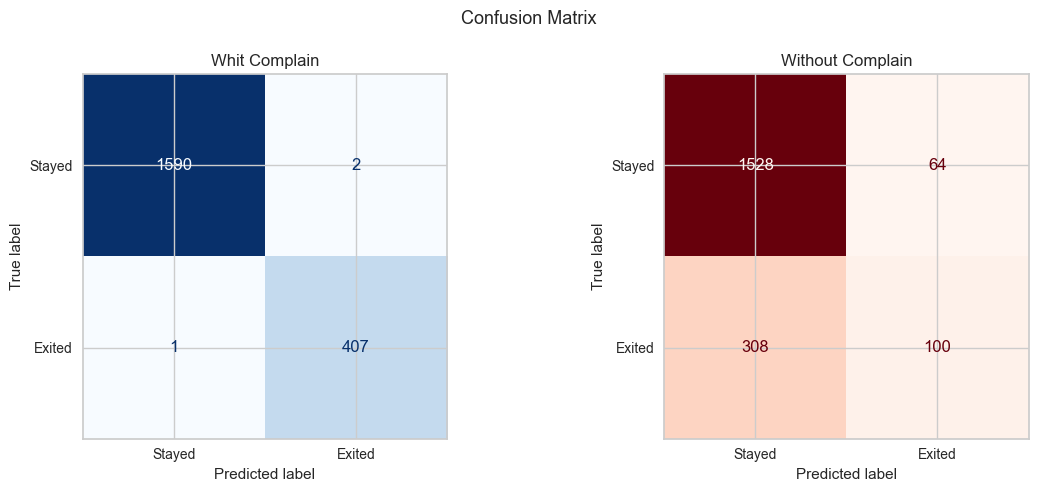

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_full    = model_full.predict(x_full_test)
y_pred_no_comp = model_no_comp.predict(x_no_comp_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_full),
                       display_labels=["Stayed", "Exited"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Whit Complain")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_no_comp),
                       display_labels=["Stayed", "Exited"]).plot(ax=axes[1], colorbar=False, cmap="Reds")
axes[1].set_title("Without Complain")

plt.suptitle("Confusion Matrix", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Logistic Regression Metrics

We evaluate both models using five metrics:

- **Accuracy** overall correct predictions
- **Precision** of all predicted churners, how many actually churned
- **Recall** of all real churners, how many were detected *(most important for churn)*
- **F1** balance between Precision and Recall
- **AUC-ROC** how well the model separates both classes (0.5 = random, 1.0 = perfect)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics = {
    "Accuracy":  [accuracy_score(y_test, y_pred_full), accuracy_score(y_test, y_pred_no_comp)],
    "Precision": [precision_score(y_test, y_pred_full), precision_score(y_test, y_pred_no_comp)],
    "Recall":    [recall_score(y_test, y_pred_full), recall_score(y_test, y_pred_no_comp)],
    "F1":        [f1_score(y_test, y_pred_full), f1_score(y_test, y_pred_no_comp)],
    "AUC-ROC":   [roc_auc_score(y_test, model_full.predict_proba(x_full_test)[:,1]),
                  roc_auc_score(y_test, model_no_comp.predict_proba(x_no_comp_test)[:,1])]
}

df_metricas = pd.DataFrame(metrics, index=["With Complain", "Whitout Complain"]).round(4)
print(df_metricas)

                  Accuracy  Precision  Recall      F1  AUC-ROC
With Complain       0.9985     0.9951  0.9975  0.9963   0.9994
Whitout Complain    0.8140     0.6098  0.2451  0.3497   0.7695


## 5. Random Forest Training

Random Forest trains 100 decision trees, each on a random sample of rows and features. The final prediction is the majority vote across all trees.

This approach reduces overfitting and captures non-linear relationships that Logistic Regression cannot.

In [25]:
from sklearn.ensemble import RandomForestClassifier

model_rf_full = RandomForestClassifier(n_estimators=100, random_state=123)
model_rf_full.fit(x_full_train, y_train)

model_rf_no_comp = RandomForestClassifier(n_estimators=100, random_state=123)
model_rf_no_comp.fit(x_no_comp_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6. Random Forest Confusion Matrix

Same structure as the Logistic Regression matrix. We compare how many churners were correctly detected by the Random Forest.

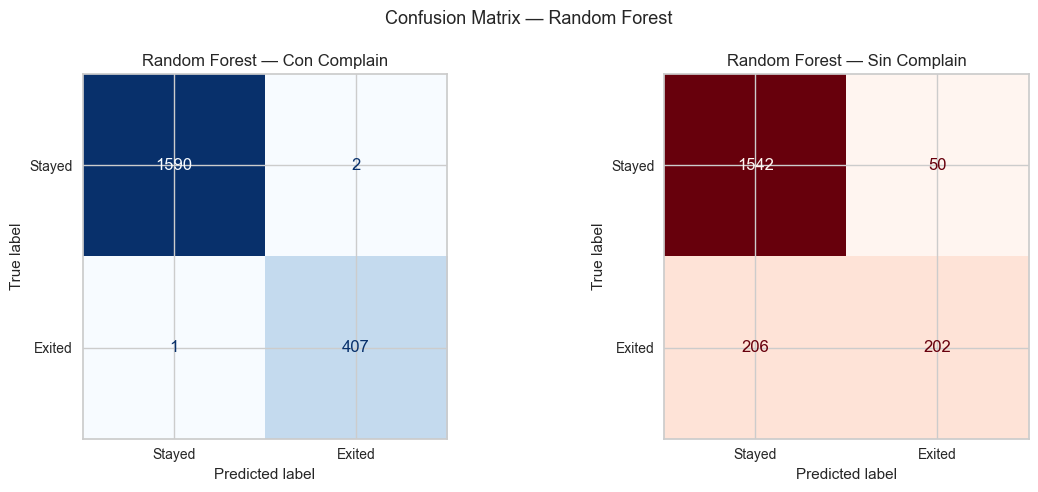

In [ ]:
y_pred_rf_full    = model_rf_full.predict(x_full_test)
y_pred_rf_no_comp = model_rf_no_comp.predict(x_no_comp_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf_full),
                       display_labels=["Stayed", "Exited"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Random Forest Con Complain")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf_no_comp),
                       display_labels=["Stayed", "Exited"]).plot(ax=axes[1], colorbar=False, cmap="Reds")
axes[1].set_title("Random Forest Sin Complain")

plt.suptitle("Confusion Matrix Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Random Forest Metrics

We apply the same five metrics to the Random Forest and compare the results against Logistic Regression.

In [27]:
metricas_rf = {
    "Accuracy":  [accuracy_score(y_test, y_pred_rf_full), accuracy_score(y_test, y_pred_rf_no_comp)],
    "Precision": [precision_score(y_test, y_pred_rf_full), precision_score(y_test, y_pred_rf_no_comp)],
    "Recall":    [recall_score(y_test, y_pred_rf_full), recall_score(y_test, y_pred_rf_no_comp)],
    "F1":        [f1_score(y_test, y_pred_rf_full), f1_score(y_test, y_pred_rf_no_comp)],
    "AUC-ROC":   [roc_auc_score(y_test, model_rf_full.predict_proba(x_full_test)[:,1]),
                  roc_auc_score(y_test, model_rf_no_comp.predict_proba(x_no_comp_test)[:,1])]
}

df_metricas_rf = pd.DataFrame(metricas_rf, index=["Con Complain", "Sin Complain"]).round(4)
print(df_metricas_rf)

              Accuracy  Precision  Recall      F1  AUC-ROC
Con Complain    0.9985     0.9951  0.9975  0.9963   0.9993
Sin Complain    0.8720     0.8016  0.4951  0.6121   0.8630
